<a href="https://colab.research.google.com/github/tap-ia2003/Machine_Learning/blob/main/1_Modelos_Regresion_Banco_Mundial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

|<img src="https://1000marcas.net/wp-content/uploads/2020/07/logo-The-World-Bank.png" width="200" height="100">| <p> Modelos de Machine Learning</p>  <p> Modelos Regresion </p> <p>Banco Mundial</p> <p>Análisis de Componentes Principales</p>|
|:---: | :--- |

## Modelos de Regresión

Este cuaderno fue hecho con indicadores macroeconómicos obtenidos desde la base de datos del Banco Mundial (World Development Indicators, WDI) con el objetivo de predecir el **PIB per cápita** de los países.

| Variable | Código WDI | Descripción |
|---|---|---|
| Inflación | `FP.CPI.TOTL.ZG` | Inflación, precios al consumidor (%) |
| Inversión | `NE.GDI.TOTL.ZS` | Formación bruta de capital |
| Exportaciones | `NE.EXP.GNFS.ZS` | Exportaciones de bienes y servicios |
| Gasto gobierno | `NE.CON.GOVT.ZS` | Consumo del gobierno|
| Desempleo | `SL.UEM.TOTL.ZS` | Desempleo (% fuerza laboral) |
| Crédito privado | `FS.AST.PRVT.GD.ZS` | Crédito al sector privado|
| PIB per cápita | `NY.GDP.PCAP.KD` | PIB per cápita (US$ constantes 2015) |

### 1. Preparación del Entorno y Descarga de Datos

La descarga de datos sera utilizando la biblioteca [wbgapi](https://pypi.org/project/wbgapi/), cabe destacar que esta se tiene que instalar una unica vez antes de utilizarla.

La biblioteca **wbgapi** opera a través de un conjunto de funciones lógicas estructuradas en submódulos esenciales para el consumo de información, donde destaca principalmente la función wb.data.DataFrame, encargada de transformar peticiones complejas de indicadores en matrices estructuradas de Pandas de forma inmediata. A esta capacidad técnica se suman funciones de exploración metódica como wb.series.info, wb.economy.info y wb.time.info, las cuales permiten realizar búsquedas semánticas de palabras clave, identificar códigos de países bajo la norma ISO y mapear bases de datos completas de manera interactiva desde la consola. Asimismo, la librería incorpora herramientas de filtrado avanzado que manejan automáticamente la agregación regional, la jerarquización de variables y la segmentación temporal, resolviendo la paginación y la conectividad con los servidores del Banco Mundial de forma transparente para el desarrollador.

In [ ]:
!pip install wbgapi

In [2]:
# Importar bibliotecas
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # Separar el set de datos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Importar métricas de rendimientos

# Importar módulo para ignorar errores
from warnings import filterwarnings
filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [ ]:
# Diccionario: código WDI → nombre descriptivo
indicadores = {
    'NY.GDP.PCAP.KD':    'PIB_PerCapita',      # TARGET (variable Y)
    'FP.CPI.TOTL.ZG':    'Inflacion',
    'NE.GDI.TOTL.ZS':    'Inversion',
    'NE.EXP.GNFS.ZS':    'Exportaciones',
    'NE.CON.GOVT.ZS':    'Gasto_Gobierno',
    'SL.UEM.TOTL.ZS':    'Desempleo',
    'FS.AST.PRVT.GD.ZS': 'Credito_Privado'}


# Descargar datos para todos los países, periodo 2000-2022
df_raw = wb.data.DataFrame(
    list(indicadores.keys()),
    time=range(2010, 2020),
    labels=True,
    columns='series'
)

# Renombrar columnas
df_raw.rename(columns=indicadores, inplace=True)

# Resetear indice
df_raw = df_raw.reset_index()


Usamos head() para visualizar los primeros registros del DataFrame, lo que nos permite realizar una inspeccion preliminar de los indicadores.

In [ ]:
# Primeros registros
df_raw.head(2)

,economy,time,Country,Time,Inflacion,Credito_Privado,Gasto_Gobierno,Exportaciones,Inversion,PIB_PerCapita,Desempleo
0,ZWE,YR2019,Zimbabwe,2019,255.3050,3.4280,6.0647,22.7692,11.5616,1357.5309,7.3730
1,ZWE,YR2018,Zimbabwe,2018,10.6189,5.8303,10.3742,26.1641,14.1484,1472.1460,6.7880


Se extraen los registros unicos por pais, en busqueda de repetidos y la necesidad de restringir el analisis exclusivamente a nivel pais.

In [ ]:
sorted(df_raw["Country"].unique())

Para seleciconar solamente paises, utilizaremos la informacion del sitio web [IBAN](https://es.iban.com/)

In [ ]:
#Cargar tablas de la pagina web
url_iban = "https://www.iban.com/country-codes"
iban_tables = pd.read_html(url_iban)
df_iban = iban_tables[0]
df_iban = df_iban[['Country','Alpha-3 code']]
df_iban.columns = ['country','economy']

In [ ]:
df_raw = pd.merge(df_raw,df_iban['economy'], how = 'inner', on = 'economy')

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   economy          2150 non-null   object 
 1   time             2150 non-null   object 
 2   Country          2150 non-null   object 
 3   Time             2150 non-null   object 
 4   Inflacion        1869 non-null   float64
 5   Credito_Privado  1694 non-null   float64
 6   Gasto_Gobierno   1736 non-null   float64
 7   Exportaciones    1803 non-null   float64
 8   Inversion        1727 non-null   float64
 9   PIB_PerCapita    2076 non-null   float64
 10  Desempleo        1860 non-null   float64
dtypes: float64(7), object(4)
memory usage: 184.9+ KB


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   economy          2150 non-null   object 
 1   time             2150 non-null   object 
 2   Country          2150 non-null   object 
 3   Time             2150 non-null   object 
 4   Inflacion        1869 non-null   float64
 5   Credito_Privado  1694 non-null   float64
 6   Gasto_Gobierno   1736 non-null   float64
 7   Exportaciones    1803 non-null   float64
 8   Inversion        1727 non-null   float64
 9   PIB_PerCapita    2076 non-null   float64
 10  Desempleo        1860 non-null   float64
dtypes: float64(7), object(4)
memory usage: 184.9+ KB


In [ ]:
df = df_raw.dropna().reset_index(drop = True)

Se construye un mapa de calor para analizar la correlacion entre los distintos indicadores

<Axes: >

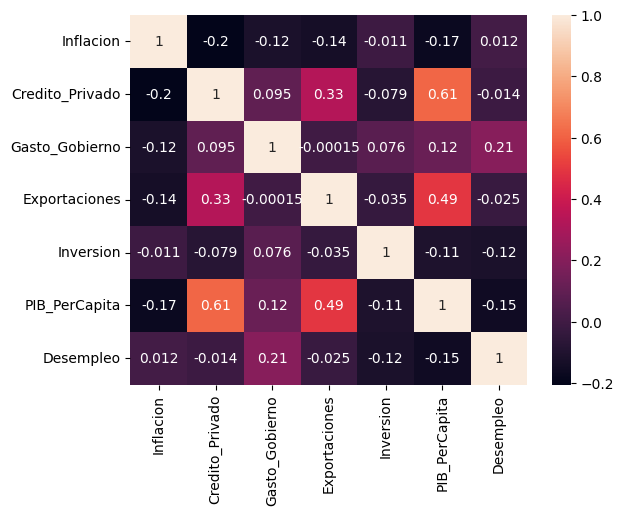

In [ ]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True)

Dada la alta correlacion entre *Credito_Privado* y *PIB_PerCapita* se procede a eliminar la variable. Todo esto con el proposito de eliminar la multicolinealidad.

In [ ]:
df = df.drop(columns = 'Credito_Privado')

Se realizan scatter plot para ver las relaciones entre las variables.

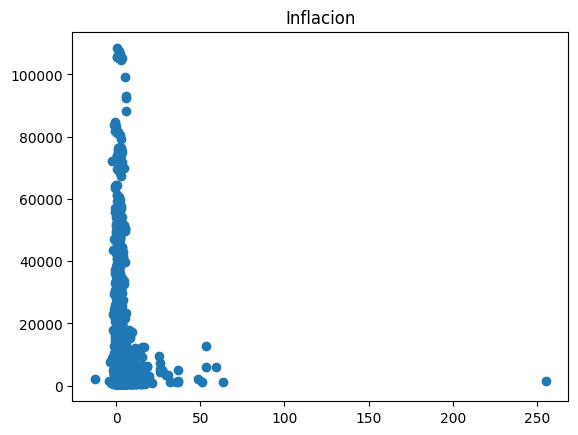

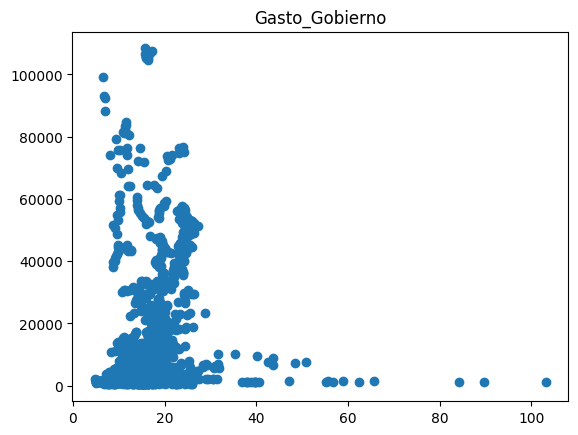

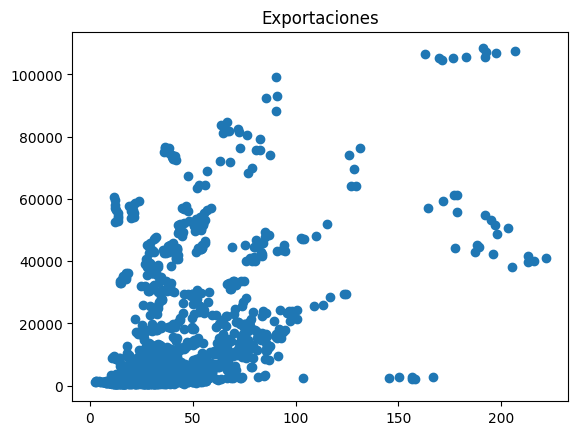

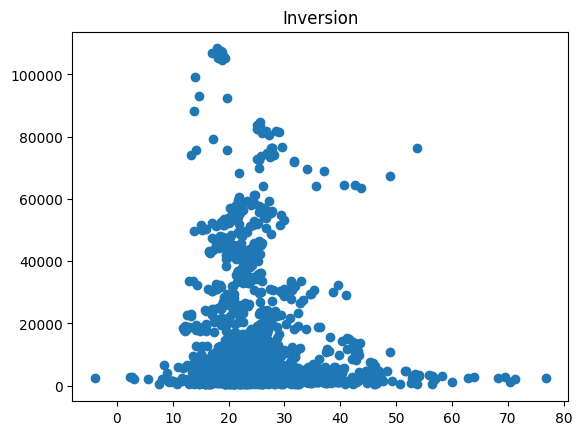

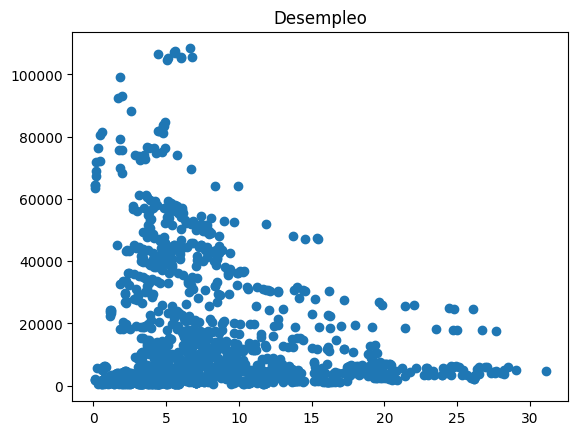

In [ ]:
numeric_col = df.select_dtypes('number').columns
numeric_col = numeric_col.drop('PIB_PerCapita')

for col in numeric_col:

    plt.scatter(y = df['PIB_PerCapita'], x = df[col])
    plt.title(col)
    plt.show()

### 3. Preparación de Features y Target

In [ ]:
#@title Crear función para visualizar métricas
def fn_metricas_info(modelo, y_verdadero, y_calculado):
    metrics = {
        'MAE': mean_absolute_error(y_verdadero, y_calculado),
        'MSE': mean_squared_error(y_verdadero, y_calculado),
        'RMSE': np.sqrt(mean_squared_error(y_verdadero, y_calculado)),
        'R2': r2_score(y_verdadero, y_calculado)
    }
    return pd.DataFrame(metrics, index=[modelo])

In [ ]:
metricas = pd.DataFrame()

In [ ]:
df_numeric = df.select_dtypes('number')
y = df_numeric['PIB_PerCapita']
X = df_numeric.drop(columns='PIB_PerCapita')

# Particionar data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)

**Regresión Lineal**

In [ ]:
from sklearn.linear_model import LinearRegression # Regresión Lineal

rl = LinearRegression(fit_intercept = True)

# Entrenar set de prueba
rl.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Testear
y_train_pred = rl.predict(X_train)
y_test_pred = rl.predict(X_test)


display(fn_metricas_info('Regresión Lineal - train', y_train, y_train_pred))
display(fn_metricas_info('Regresión Lineal - test', y_test, y_test_pred))

# Guardar resultados
metricas = fn_metricas_info('Regresión Lineal - test', y_test, y_test_pred)

,MAE,MSE,RMSE,R2
Regresión Lineal - train,11877.1972,271214004.7636,16468.5763,0.3108


,MAE,MSE,RMSE,R2
Regresión Lineal - test,11557.0035,283729249.2200,16844.2646,0.3043


In [ ]:
coeficientes = rl.coef_
variables = X.columns
pd.DataFrame({'variables': variables, 'coeficientes reg lineal': coeficientes})

,variables,coeficientes reg lineal
0,Inflacion,-168.4616
1,Gasto_Gobierno,396.6809
2,Exportaciones,315.5798
3,Inversion,-276.3348
4,Desempleo,-614.5334


**Regresión Ridge**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

# Particiones para validación cruzada
particiones = KFold(n_splits=10, shuffle=True, random_state=42)

# Valores de alpha solicitados
param_grid = {'alpha': [0.1,1,10,20,30]}

# Modelo Ridge
ridge = Ridge()

# Búsqueda de hiperparámetros
grid_search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=particiones,
    scoring='neg_mean_squared_error'
)

# Entrenamiento
grid_search_ridge.fit(X_train_scaled, y_train)

# Mejor modelo
best_ridge = grid_search_ridge.best_estimator_

print(f"El mejor valor de alpha es: {grid_search_ridge.best_params_['alpha']}")

# Predicciones
y_train_pred = best_ridge.predict(X_train_scaled)
y_test_pred = best_ridge.predict(X_test_scaled)

# Métricas
display(fn_metricas_info("Modelo Ridge - Train", y_train, y_train_pred))
display(fn_metricas_info("Modelo Ridge - Test", y_test, y_test_pred))

El mejor valor de alpha es: 30


,MAE,MSE,RMSE,R2
Modelo Ridge - Train,11867.7419,271309625.3605,16471.4791,0.3106


,MAE,MSE,RMSE,R2
Modelo Ridge - Test,11518.3553,283052993.5511,16824.1788,0.3059


In [ ]:
coeficientes = best_ridge.coef_
variables = X.columns
pd.DataFrame({'variables': variables, 'coeficientes ridge': coeficientes})

,variables,coeficientes ridge
0,Inflacion,-1631.6489
1,Gasto_Gobierno,2877.5064
2,Exportaciones,9326.4586
3,Inversion,-2273.3480
4,Desempleo,-3565.4554


In [ ]:
metricas = pd.concat([metricas, fn_metricas_info("Modelo Ridge - Test", y_test, y_test_pred)], axis = 0)

In [ ]:
metricas

,MAE,MSE,RMSE,R2
Regresión Lineal - test,11557.0035,283729249.2200,16844.2646,0.3043
Modelo Ridge - Test,11518.3553,283052993.5511,16824.1788,0.3059


**Regresión Lasso**

In [ ]:
from sklearn.linear_model import Lasso

# Particiones para validación cruzada
particiones = KFold(n_splits=10, shuffle=True, random_state=42)

# Valores de alpha solicitados
param_grid = {'alpha': [0.1,1,10,20,30]}

# Modelo Ridge
lasso = Lasso()

# Búsqueda de hiperparámetros
grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=particiones,
    scoring='neg_mean_squared_error'
)

# Entrenamiento
grid_search_lasso.fit(X_train_scaled, y_train)

# Mejor modelo
best_lasso= grid_search_lasso.best_estimator_

print(f"El mejor valor de alpha es: {grid_search_lasso.best_params_['alpha']}")

# Predicciones
y_train_pred = best_lasso.predict(X_train_scaled)
y_test_pred = best_lasso.predict(X_test_scaled)

# Métricas
display(fn_metricas_info("Modelo Lasso - Train", y_train, y_train_pred))
display(fn_metricas_info("Modelo Lasso - Test", y_test, y_test_pred))

El mejor valor de alpha es: 30


,MAE,MSE,RMSE,R2
Modelo Lasso - Train,11874.1480,271219026.7041,16468.7288,0.3108


,MAE,MSE,RMSE,R2
Modelo Lasso - Test,11551.0265,283762210.2041,16845.2430,0.3042


In [ ]:
metricas = pd.concat([metricas, fn_metricas_info("Modelo Lasso - Test", y_test, y_test_pred)], axis = 0)
metricas

,MAE,MSE,RMSE,R2
Regresión Lineal - test,11557.0035,283729249.2200,16844.2646,0.3043
Modelo Ridge - Test,11518.3553,283052993.5511,16824.1788,0.3059
Modelo Lasso - Test,11551.0265,283762210.2041,16845.2430,0.3042


In [ ]:
coeficientes = best_lasso.coef_
variables = X.columns
pd.DataFrame({'variables': variables, 'coeficientes': coeficientes})

,variables,coeficientes
0,Inflacion,-1609.7424
1,Gasto_Gobierno,2948.2790
2,Exportaciones,9560.1105
3,Inversion,-2313.8472
4,Desempleo,-3658.4255


**Nota Optativa: Comparación de coeficientes en escala original**

*Ridge y Lasso se entrenaron con datos normalizados, por lo que sus coeficientes están en términos de desviaciones estándar. Para una comparación justa con Regresión Lineal, se desnormalizan dividiendo por la desviación estándar de cada variable.*

In [ ]:
# Obtener desviaciones estándar de los features normalizados
std_scaling = scaler.scale_

# Desnormalizar coeficientes de Ridge y Lasso
coef_ridge_original = best_ridge.coef_ / std_scaling
coef_lasso_original = best_lasso.coef_ / std_scaling

# Crear tabla comparativa
comparacion_coef = pd.DataFrame({
    'Variable': X.columns,
    'Regresión Lineal': rl.coef_,
    'Ridge (desnorm.)': coef_ridge_original,
    'Lasso (desnorm.)': coef_lasso_original
})

print("COMPARACIÓN DE COEFICIENTES (escala original)\n")
display(comparacion_coef)

COMPARACIÓN DE COEFICIENTES (escala original)



,Variable,Regresión Lineal,Ridge (desnorm.),Lasso (desnorm.)
0,Inflacion,-168.4616,-168.4141,-166.1530
1,Gasto_Gobierno,396.6809,382.1010,391.4988
2,Exportaciones,315.5798,307.0641,314.7569
3,Inversion,-276.3348,-267.0354,-271.7926
4,Desempleo,-614.5334,-592.0649,-607.5032


**INTERPRETACIÓN:**

- Ridge y Lasso mantienen direcciones (signos) similares a Regresión Lineal
- Ridge/Lasso amplifican ligeramente la magnitud de los coeficientes
- Exportaciones es el predictor MÁS FUERTE (coef. > 310)
- Desempleo tiene el impacto NEGATIVO más fuerte (coef. < -600)

**Árbol de decisión**

In [ ]:
# Biblioteca
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV


In [ ]:
# Copair set de datos
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

# Instanciar modelo
tree = DecisionTreeRegressor(random_state=42)

# Grilla con hiperparámetros
param_grid = {
    'max_depth': [3,5,7],
    'min_samples_split': [15,20],
    'min_samples_leaf': [15,20],
    #'max_features': [None, 'sqrt', 'log2']
}

# Ejecutar CV
gs_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar modelo
gs_tree.fit(X_train_tree, y_train)

print(f"Mejores hiperparámetros: {gs_tree.best_params_}")
print("Mejor MAE (CV):", abs(gs_tree.best_score_))

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Mejores hiperparámetros: {'max_depth': 7, 'min_samples_leaf': 15, 'min_samples_split': 15}
Mejor MAE (CV): 212232838.03112012


In [ ]:
# Entrenar mejor modelo
best_tree = gs_tree.best_estimator_

best_tree.fit(X_train_tree, y_train)

# Predicciones
y_train_pred = best_tree.predict(X_train_tree)
y_test_pred = best_tree.predict(X_test_tree)

# Aplicar funición de métricas
display(fn_metricas_info("Árbol Decisión - Train", y_train, y_train_pred))
display(fn_metricas_info("Árbol Decisión- Test", y_test, y_test_pred))


,MAE,MSE,RMSE,R2
Árbol Decisión - Train,6859.0928,138128310.9497,11752.8001,0.6490


,MAE,MSE,RMSE,R2
Árbol Decisión- Test,8275.1464,199880401.7186,14137.9066,0.5099


In [ ]:
metricas = pd.concat([metricas, fn_metricas_info("Árbol Decisión- Test", y_test, y_test_pred)], axis = 0)
metricas

,MAE,MSE,RMSE,R2
Regresión Lineal - test,11557.0035,283729249.2200,16844.2646,0.3043
Modelo Ridge - Test,11518.3553,283052993.5511,16824.1788,0.3059
Modelo Lasso - Test,11551.0265,283762210.2041,16845.2430,0.3042
Árbol Decisión- Test,8275.1464,199880401.7186,14137.9066,0.5099


En función de las métricas evaluadas, el Árbol de Decisión es el que presenta la mejor capacidad predictiva. La relación entre las variables macroeconómicas y el PIB per cápita parece tener fuertes componentes no lineales que la regresión múltiple no logra capturar, por lo que un modelo basado en particiones jerárquicas como el árbol se adapta de mucha mejor manera a la naturaleza de los datos.

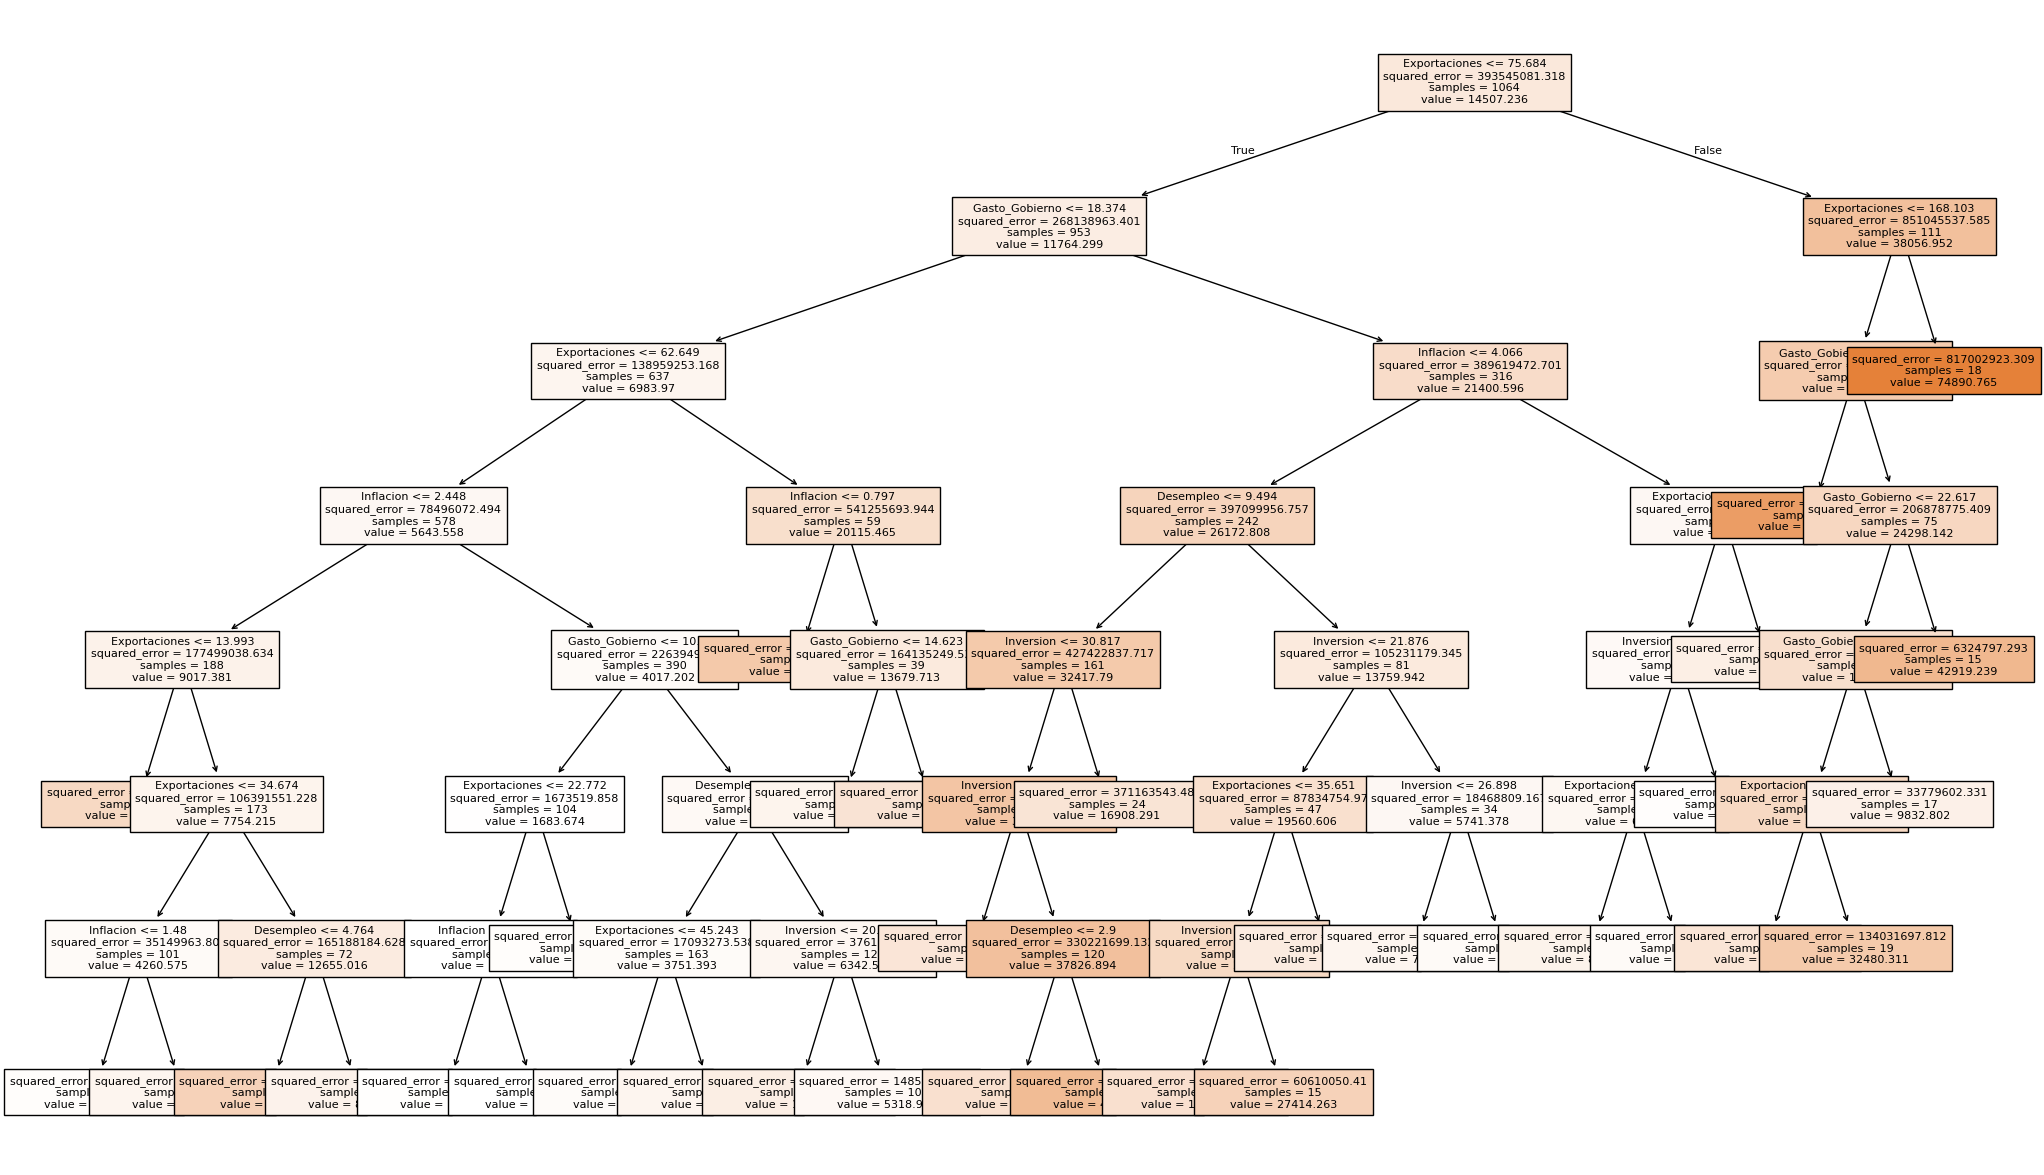

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25,15))
plot_tree(best_tree, filled=True, max_depth=gs_tree.best_params_['max_depth'], fontsize=8, feature_names=best_tree.feature_names_in_)
plt.show()